In [2]:
import os
import copy
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.models import (DenseNet121_Weights,  ResNet50_Weights,  ResNet101_Weights, EfficientNet_B0_Weights)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
class CTDataset(Dataset):
    def __init__(self, image_paths, labels, image_size=256, augment=False, use_clahe=False):
        self.image_paths = image_paths
        self.labels = labels
        self.image_size = image_size
        self.augment = augment
        self.use_clahe = use_clahe

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        self.clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

    def __len__(self):
        return len(self.image_paths)

    def apply_clahe(self, img):
        img_u8 = (img * 255.0).clip(0, 255).astype(np.uint8)
        img_u8 = self.clahe.apply(img_u8)
        return img_u8.astype(np.float32) / 255.0

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise FileNotFoundError(f"Could not read image: {path}")

        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        img = cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        img = img.astype(np.float32)

        if img.max() > 255:
            img = img / 65535.0
        else:
            img = img / 255.0

        if self.use_clahe:
            img = self.apply_clahe(img)

        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                angle = np.random.uniform(-10, 10)
                M = cv2.getRotationMatrix2D(
                    (self.image_size // 2, self.image_size // 2),
                    angle,
                    1.0
                )
                img = cv2.warpAffine(
                    img,
                    M,
                    (self.image_size, self.image_size),
                    borderMode=cv2.BORDER_REFLECT
                )

            if np.random.rand() < 0.5:
                alpha = np.random.uniform(0.9, 1.1)
                beta = np.random.uniform(-0.05, 0.05)
                img = np.clip(alpha * img + beta, 0, 1)

            if np.random.rand() < 0.3:
                noise = np.random.normal(0, 0.02, img.shape).astype(np.float32)
                img = np.clip(img + noise, 0, 1)

        img = torch.from_numpy(img.astype(np.float32)).unsqueeze(0)
        img = img.repeat(3, 1, 1)

        img = (img - self.mean) / self.std

        label = torch.tensor(label, dtype=torch.long)

        return img, label

In [5]:
train_dir = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\train"
val_dir   = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\val"
test_dir  = r"C:\Users\rgzep\Documents\IP data\data_png_wholeslice_lung256_processed\Centre10_split\test"

img_size = 256
batch_size = 16
num_workers = 0

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

In [6]:
train_base = ImageFolder(train_dir)
val_base = ImageFolder(val_dir)
test_base = ImageFolder(test_dir)

train_paths = [s[0] for s in train_base.samples]
train_labels = [s[1] for s in train_base.samples]

val_paths = [s[0] for s in val_base.samples]
val_labels = [s[1] for s in val_base.samples]

test_paths = [s[0] for s in test_base.samples]
test_labels = [s[1] for s in test_base.samples]

class_names = train_base.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['no_nodule', 'nodule']
Train: 4050
Val: 860
Test: 890


In [7]:
train_data = CTDataset(train_paths, train_labels, image_size=img_size)
val_data   = CTDataset(val_paths, val_labels, image_size=img_size)
test_data  = CTDataset(test_paths, test_labels, image_size=img_size)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [8]:
print(test_base.classes)

['no_nodule', 'nodule']


## Soft voting

In [9]:
class WeightedSoftVotingEnsemble(nn.Module):
    def __init__(self, models, weights=None):
        super().__init__()

        self.models = nn.ModuleList(models)

        if weights is None:
            weights = [1.0] * len(models)

        weights = torch.tensor(weights, dtype=torch.float32)
        weights = weights / weights.sum()

        self.register_buffer("weights", weights)

        for model in self.models:
            model.eval()
            for p in model.parameters():
                p.requires_grad = False

    def forward(self, x):
        weighted_probs = torch.zeros(
            x.size(0),
            2,
            device=x.device
        )

        for model, weight in zip(self.models, self.weights):
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            weighted_probs += weight * probs

        return weighted_probs

In [10]:
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Sequential(nn.Dropout(0.6), nn.Linear(resnet50.fc.in_features, num_classes))
resnet50.load_state_dict(torch.load("saved_models/resnet50_best_sen.pth", map_location=device))
resnet50.to(device)
resnet50.eval()

resnet101 = models.resnet101(weights=None)
resnet101.fc = nn.Sequential(nn.Dropout(0.6), nn.Linear(resnet101.fc.in_features, num_classes))
resnet101.load_state_dict(torch.load("saved_models/resnet101_best_sen.pth", map_location=device))
resnet101.to(device)
resnet101.eval()

densenet121 = models.densenet121(weights=None)
densenet121.classifier = nn.Sequential(nn.Dropout(0.6), nn.Linear(densenet121.classifier.in_features, num_classes))
densenet121.load_state_dict(torch.load("saved_models/densenet121_best_sen.pth",map_location=device))
densenet121.to(device)
densenet121.eval()

efficientnet = models.efficientnet_b0(weights=None)
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, num_classes))
efficientnet.load_state_dict(torch.load("saved_models/efficientnet_b0_best_sen.pth", map_location=device))
efficientnet.to(device)
efficientnet.eval()

C:\Users\rgzep\AppData\Local\Temp\ipykernel_30084\1057219242.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50.load_state_dict(torch.load("saved_models/resnet50_b

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [10]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch
import torch.nn.functional as F

def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:,1]

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    recall = recall_score(all_labels, all_preds)

    return acc, f1, auc, recall

In [18]:
def evaluate_ensemble(model, test_loader, device, class_names):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            probs = model(images)                 # weighted probabilities
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # probability of positive class
            all_probs.extend(probs[:, 1].cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
   
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(report)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }

In [12]:
def predict_ensemble(model, image_tensor, class_names):
    model.eval()
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        probs = model(image_tensor)
        confidence, predicted_class = torch.max(probs, dim=1)

    return {
        "prediction": class_names[predicted_class.item()],
        "confidence": confidence.item(),
        "probabilities": probs.cpu().numpy()
    }

In [13]:
for name, model in [
    ("resnet50", resnet50),
    ("densenet121", densenet121),
    ("resnet101", resnet101),
    ("efficientnetb0", efficientnet)
]:
    acc, f1, auc, recall = evaluate(model, val_loader)
    print(name, acc, f1, auc, recall)

resnet50 0.836046511627907 0.8856447688564477 0.9083022774327122 0.8666666666666667
densenet121 0.836046511627907 0.8845208845208845 0.9054658385093166 0.8571428571428571
resnet101 0.8209302325581396 0.8741830065359477 0.8809282263630089 0.8492063492063492
efficientnetb0 0.8151162790697675 0.8671679197994987 0.9119392684610076 0.8238095238095238


Accuracy : 0.836
Precision: 0.7893
Recall   : 0.8094
F1 Score : 0.7981
ROC AUC  : 0.9083

Confusion Matrix:
[[173  57]
 [ 84 546]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.67      0.75      0.71       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.84      0.84      0.84       860



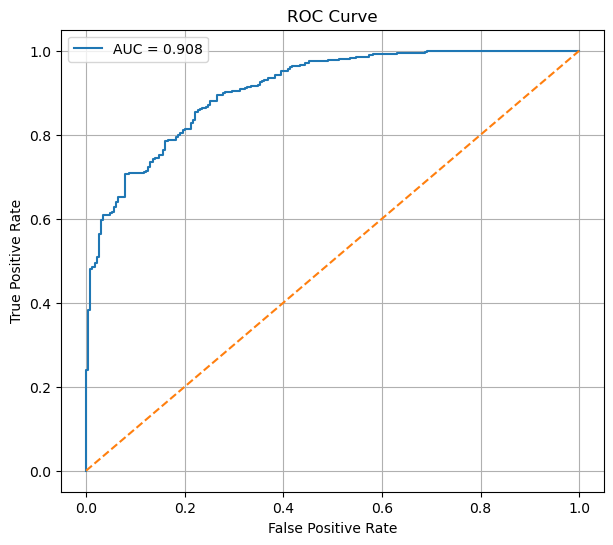

Accuracy : 0.7764
Precision: 0.724
Recall   : 0.7288
F1 Score : 0.7262
ROC AUC  : 0.8265

Confusion Matrix:
[[155  95]
 [104 536]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.60      0.62      0.61       250
      nodule       0.85      0.84      0.84       640

    accuracy                           0.78       890
   macro avg       0.72      0.73      0.73       890
weighted avg       0.78      0.78      0.78       890



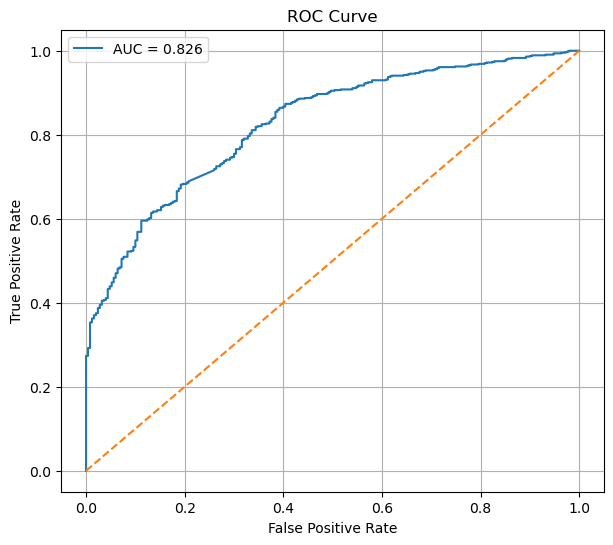

In [14]:
#Baseline only
weights=[1, 0, 0]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8384
Precision: 0.7921
Recall   : 0.8124
F1 Score : 0.8009
ROC AUC  : 0.9238

Confusion Matrix:
[[174  56]
 [ 83 547]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.76      0.71       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.85      0.84      0.84       860



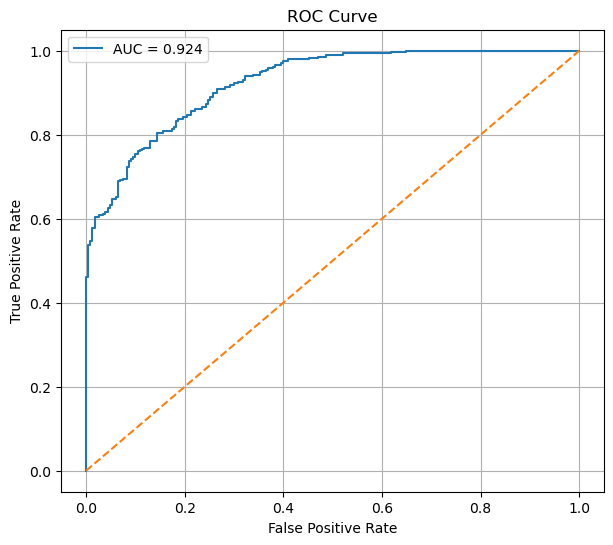

Accuracy : 0.7674
Precision: 0.7145
Recall   : 0.7249
F1 Score : 0.7191
ROC AUC  : 0.8288

Confusion Matrix:
[[157  93]
 [114 526]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.63      0.60       250
      nodule       0.85      0.82      0.84       640

    accuracy                           0.77       890
   macro avg       0.71      0.72      0.72       890
weighted avg       0.77      0.77      0.77       890



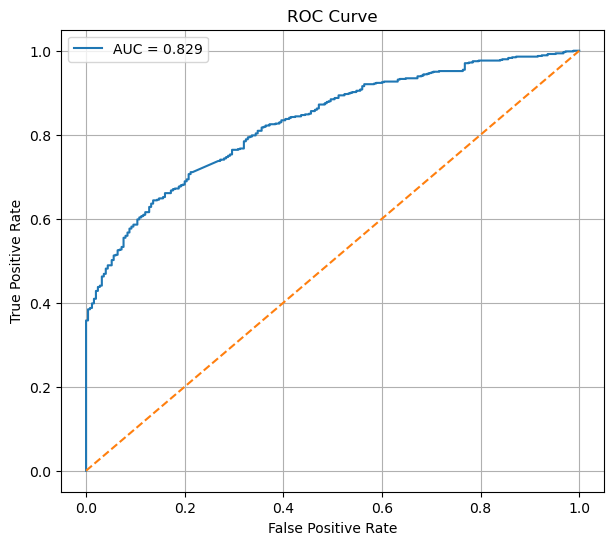

In [15]:
#Equal weights
weights=[1, 1, 1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8395
Precision: 0.7935
Recall   : 0.8132
F1 Score : 0.8021
ROC AUC  : 0.924

Confusion Matrix:
[[174  56]
 [ 82 548]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.76      0.72       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.85      0.84      0.84       860



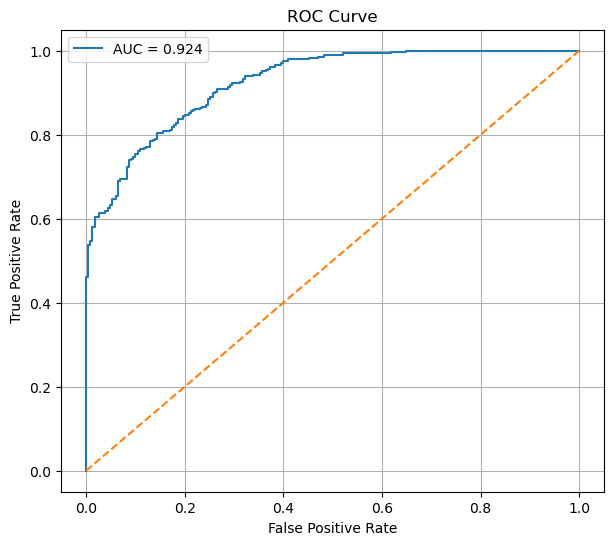

Accuracy : 0.7685
Precision: 0.7157
Recall   : 0.7257
F1 Score : 0.7202
ROC AUC  : 0.829

Confusion Matrix:
[[157  93]
 [113 527]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.63      0.60       250
      nodule       0.85      0.82      0.84       640

    accuracy                           0.77       890
   macro avg       0.72      0.73      0.72       890
weighted avg       0.77      0.77      0.77       890



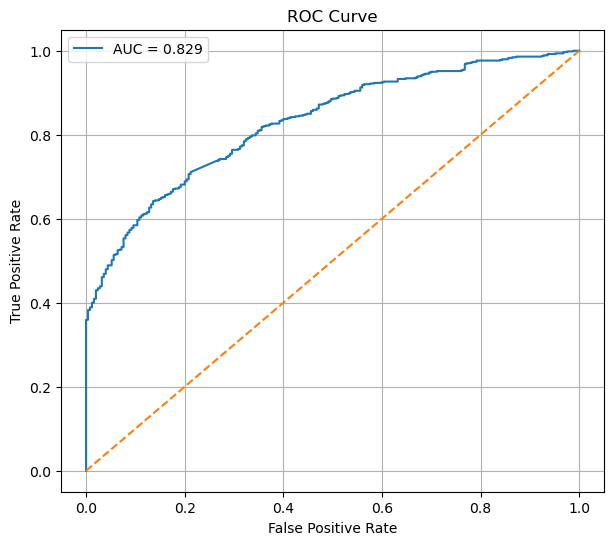

In [17]:
#AUC weights
weights=[0.9083022774327122, 0.9054658385093166, 0.8809282263630089, 0.9119392684610076]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8395
Precision: 0.7935
Recall   : 0.8132
F1 Score : 0.8021
ROC AUC  : 0.9239

Confusion Matrix:
[[174  56]
 [ 82 548]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.76      0.72       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.85      0.84      0.84       860



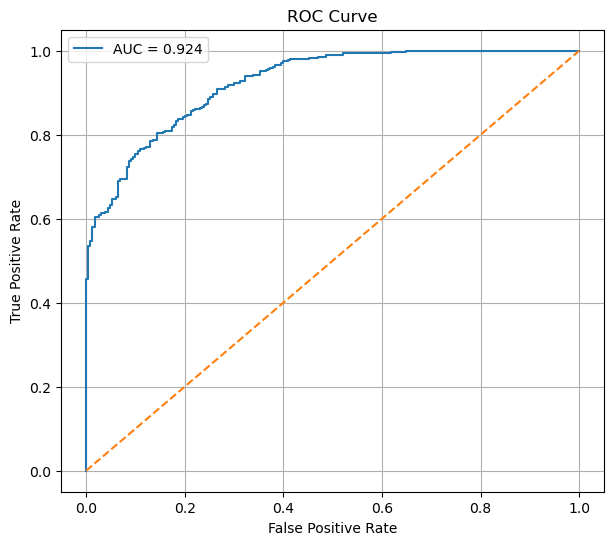

Accuracy : 0.7674
Precision: 0.7145
Recall   : 0.7249
F1 Score : 0.7191
ROC AUC  : 0.8289

Confusion Matrix:
[[157  93]
 [114 526]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.63      0.60       250
      nodule       0.85      0.82      0.84       640

    accuracy                           0.77       890
   macro avg       0.71      0.72      0.72       890
weighted avg       0.77      0.77      0.77       890



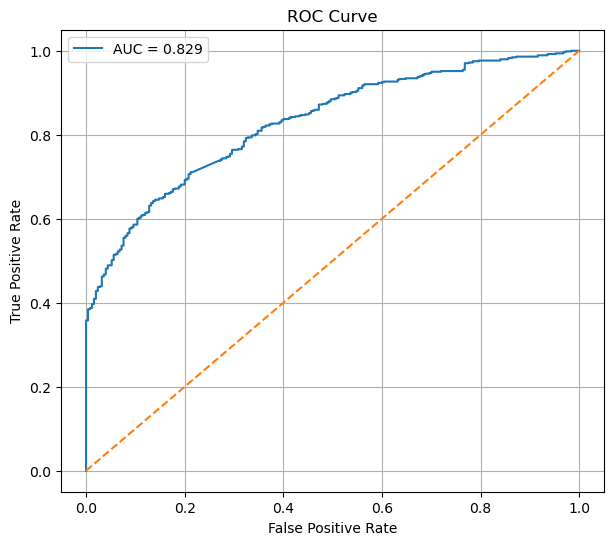

In [19]:
#Acc weights
weights = [0.836046511627907, 0.836046511627907, 0.8209302325581396, 0.8151162790697675]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8395
Precision: 0.7935
Recall   : 0.8132
F1 Score : 0.8021
ROC AUC  : 0.9239

Confusion Matrix:
[[174  56]
 [ 82 548]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.76      0.72       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.85      0.84      0.84       860



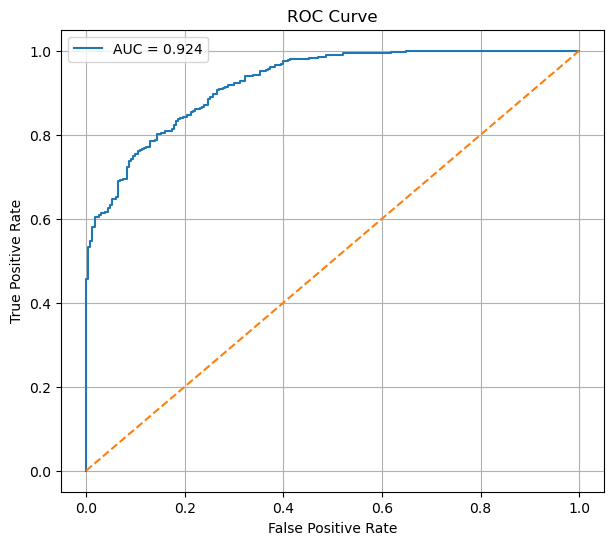

Accuracy : 0.7674
Precision: 0.7145
Recall   : 0.7249
F1 Score : 0.7191
ROC AUC  : 0.8288

Confusion Matrix:
[[157  93]
 [114 526]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.63      0.60       250
      nodule       0.85      0.82      0.84       640

    accuracy                           0.77       890
   macro avg       0.71      0.72      0.72       890
weighted avg       0.77      0.77      0.77       890



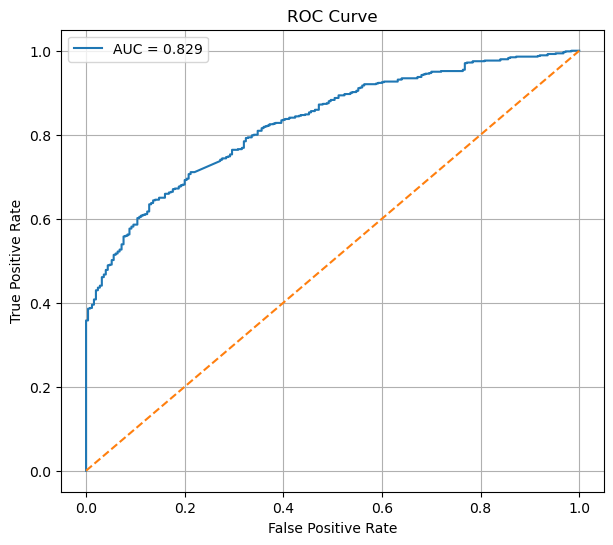

In [20]:
#sensitivity
weights = [0.8666666666666667, 0.8571428571428571, 0.8492063492063492, 0.8238095238095238]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8395
Precision: 0.7935
Recall   : 0.8132
F1 Score : 0.8021
ROC AUC  : 0.9239

Confusion Matrix:
[[174  56]
 [ 82 548]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.76      0.72       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.85      0.84      0.84       860



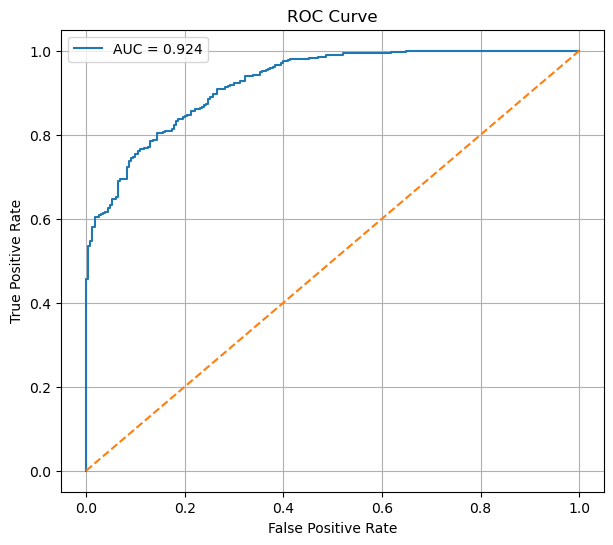

Accuracy : 0.7674
Precision: 0.7145
Recall   : 0.7249
F1 Score : 0.7191
ROC AUC  : 0.8289

Confusion Matrix:
[[157  93]
 [114 526]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.63      0.60       250
      nodule       0.85      0.82      0.84       640

    accuracy                           0.77       890
   macro avg       0.71      0.72      0.72       890
weighted avg       0.77      0.77      0.77       890



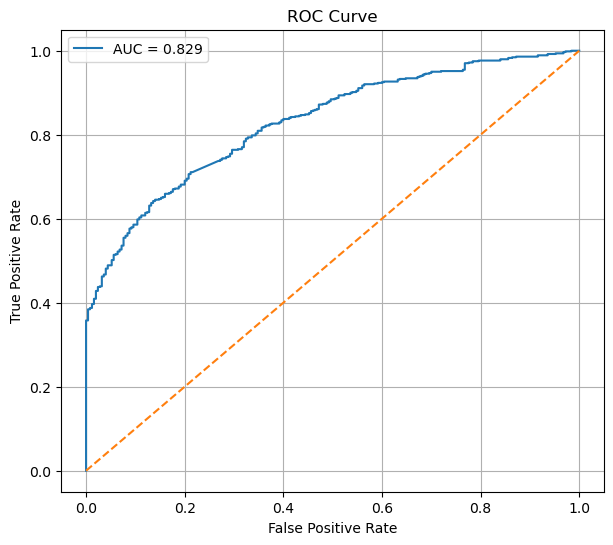

In [21]:
#f1
weights = [0.8856447688564477, 0.8845208845208845, 0.8741830065359477, 0.8671679197994987]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101, efficientnet],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

# Tuning (3 models)

In [11]:
models_list = [resnet50, densenet121, resnet101]

for m in models_list:
    m.eval()
    for p in m.parameters():
        p.requires_grad = False

In [12]:
def get_model_probs(models_list, loader, device):
    all_model_probs = [[] for _ in models_list]
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            for i, model in enumerate(models_list):
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                all_model_probs[i].append(probs.cpu().numpy())

            all_labels.append(labels.numpy())

    all_model_probs = [
        np.concatenate(p, axis=0)
        for p in all_model_probs
    ]

    all_labels = np.concatenate(all_labels)

    return all_model_probs, all_labels

In [13]:
def evaluate_probs(y_true, probs, class_names):
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    auc = roc_auc_score(y_true, probs[:, 1])
    malignant_recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))
    print("Malignant Recall:", round(malignant_recall, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "malignant_recall": malignant_recall
    }

In [14]:
val_probs, y_val = get_model_probs(models_list, val_loader, device)
test_probs, y_test = get_model_probs(models_list, test_loader, device)

In [15]:
best = {
    "weights": None,
    "f1": -1,
    "auc": -1,
    "malignant_recall": -1
}

step = 0.01

for w1 in np.arange(0, 1.0001, step):
    for w2 in np.arange(0, 1.0001 - w1, step):
        w3 = 1.0 - w1 - w2

        if w3 < 0:
            continue

        weights = np.array([w1, w2, w3])

        ensemble_val_probs = (
            weights[0] * val_probs[0] +
            weights[1] * val_probs[1] +
            weights[2] * val_probs[2]
        )

        y_pred = np.argmax(ensemble_val_probs, axis=1)

        f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        auc = roc_auc_score(y_val, ensemble_val_probs[:, 1])
        recall = recall_score(y_val, y_pred, average="macro", zero_division=0)
        malignant_recall = recall_score(y_val, y_pred, pos_label=1, zero_division=0)

        # Main tuning metric
        '''if malignant_recall > best["malignant_recall"] and f1 > 0.75:
            best = {
                "weights": weights,
                "f1": f1,
                "auc": auc,
                "malignant_recall": malignant_recall,
                "recall": recall
            }'''
        if auc > best["auc"]:
            best = {
                "weights": weights,
                "f1": f1,
                "auc": auc,
                "malignant_recall": malignant_recall,
                "recall": recall
            }

print("Best validation weights:")
print("ResNet50   :", round(best["weights"][0], 2))
print("DenseNet121:", round(best["weights"][1], 2))
print("ResNet101  :", round(best["weights"][2], 2))

print("\nBest validation scores:")
print("F1:", round(best["f1"], 4))
print("AUC:", round(best["auc"], 4))
print("Recall:", round(best["recall"], 4))
print("Malig recall:", round(best["malignant_recall"], 4))

Best validation weights:
ResNet50   : 0.54
DenseNet121: 0.43
ResNet101  : 0.03

Best validation scores:
F1: 0.8078
AUC: 0.9218
Recall: 0.8191
Malig recall: 0.873


In [16]:
best_weights = best["weights"]

ensemble_test_probs = (
    best_weights[0] * test_probs[0] +
    best_weights[1] * test_probs[1] +
    best_weights[2] * test_probs[2]
)

print("Final Tuned Ensemble Test Results")
test_metrics = evaluate_probs(y_test, ensemble_test_probs, class_names)

Final Tuned Ensemble Test Results
Accuracy : 0.7809
Precision: 0.7296
Recall   : 0.7355
F1 Score : 0.7324
ROC AUC  : 0.8302
Malignant Recall: 0.8391

Confusion Matrix:
[[158  92]
 [103 537]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.61      0.63      0.62       250
      nodule       0.85      0.84      0.85       640

    accuracy                           0.78       890
   macro avg       0.73      0.74      0.73       890
weighted avg       0.78      0.78      0.78       890



Accuracy : 0.8442
Precision: 0.799
Recall   : 0.8191
F1 Score : 0.8078
ROC AUC  : 0.9218

Confusion Matrix:
[[176  54]
 [ 80 550]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.69      0.77      0.72       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.80      0.82      0.81       860
weighted avg       0.85      0.84      0.85       860



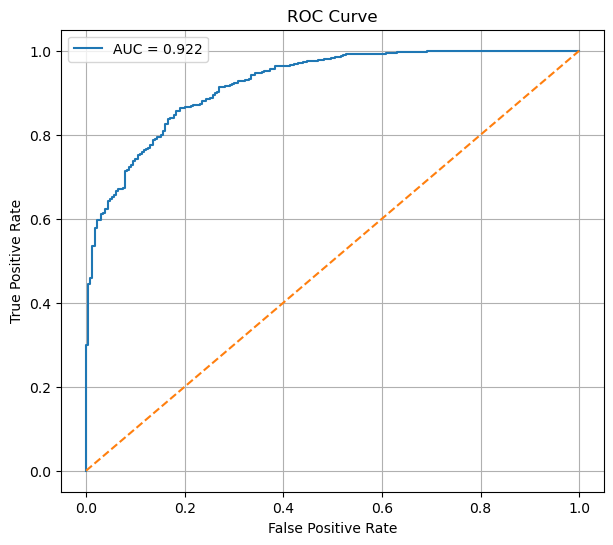

Accuracy : 0.7809
Precision: 0.7296
Recall   : 0.7355
F1 Score : 0.7324
ROC AUC  : 0.8302

Confusion Matrix:
[[158  92]
 [103 537]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.61      0.63      0.62       250
      nodule       0.85      0.84      0.85       640

    accuracy                           0.78       890
   macro avg       0.73      0.74      0.73       890
weighted avg       0.78      0.78      0.78       890



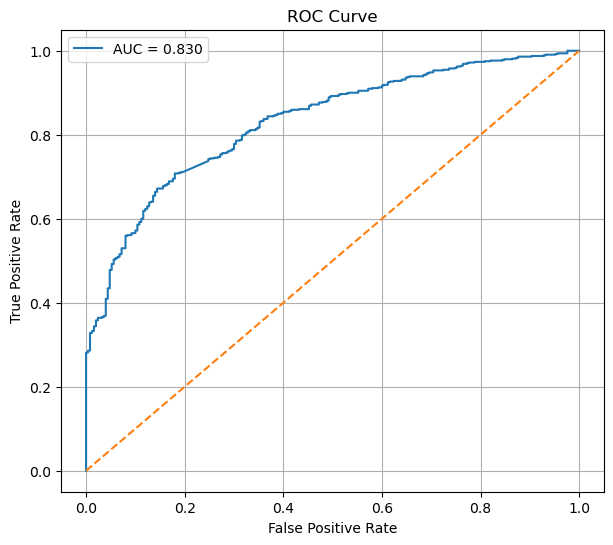

In [19]:
weights = best_weights
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names)

## 2 model combo

Accuracy : 0.8465
Precision: 0.8018
Recall   : 0.8221
F1 Score : 0.8107
ROC AUC  : 0.9212

Confusion Matrix:
[[177  53]
 [ 79 551]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.69      0.77      0.73       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.85       860
   macro avg       0.80      0.82      0.81       860
weighted avg       0.85      0.85      0.85       860



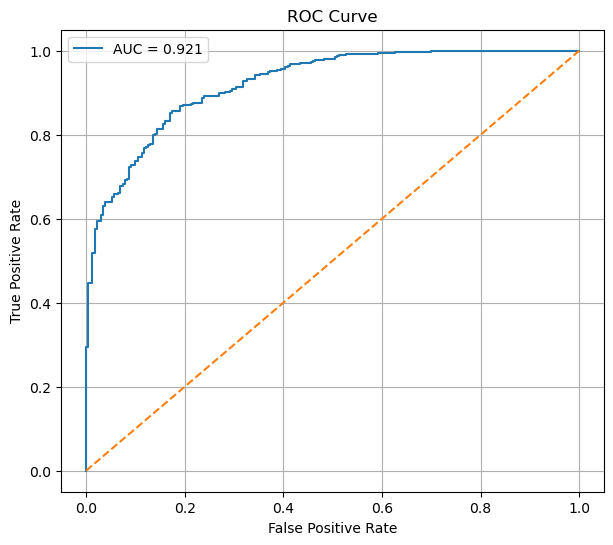

Accuracy : 0.782
Precision: 0.7311
Recall   : 0.7388
F1 Score : 0.7347
ROC AUC  : 0.8287

Confusion Matrix:
[[160  90]
 [104 536]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.61      0.64      0.62       250
      nodule       0.86      0.84      0.85       640

    accuracy                           0.78       890
   macro avg       0.73      0.74      0.73       890
weighted avg       0.79      0.78      0.78       890



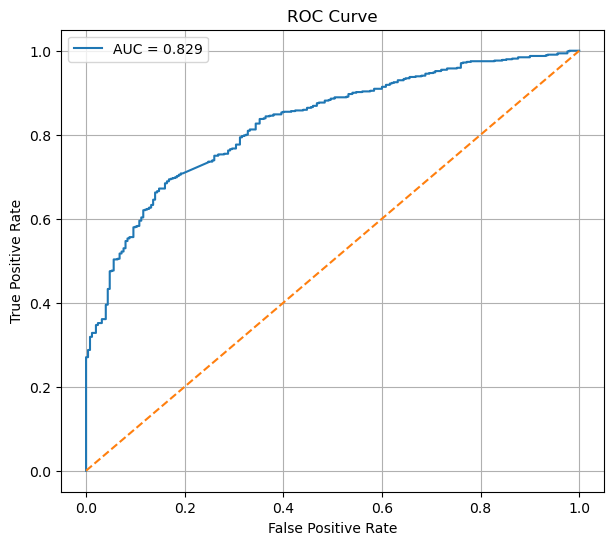

In [50]:
weights=[1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

Accuracy : 0.8372
Precision: 0.7907
Recall   : 0.8102
F1 Score : 0.7992
ROC AUC  : 0.907

Confusion Matrix:
[[173  57]
 [ 83 547]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.68      0.75      0.71       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.84       860
   macro avg       0.79      0.81      0.80       860
weighted avg       0.84      0.84      0.84       860



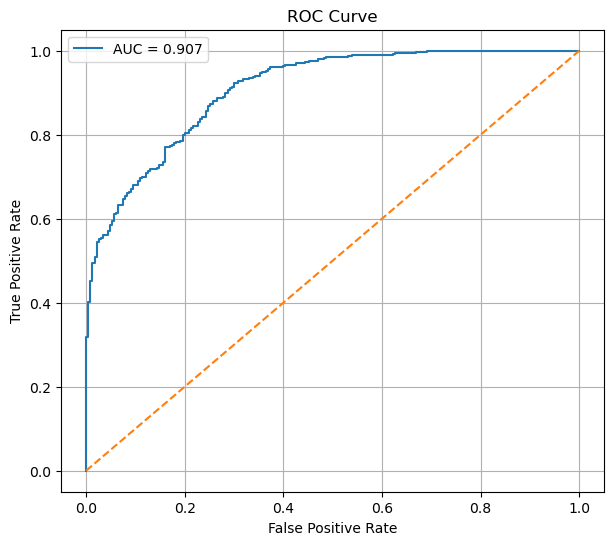

Accuracy : 0.7663
Precision: 0.7106
Recall   : 0.7095
F1 Score : 0.71
ROC AUC  : 0.824

Confusion Matrix:
[[145 105]
 [103 537]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.58      0.58      0.58       250
      nodule       0.84      0.84      0.84       640

    accuracy                           0.77       890
   macro avg       0.71      0.71      0.71       890
weighted avg       0.77      0.77      0.77       890



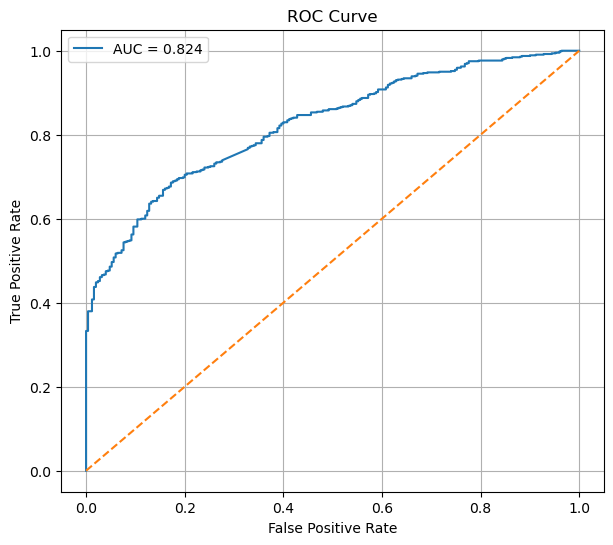

In [46]:
weights=[1, 1]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, resnet101],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

# Tuning

In [51]:
def get_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)

In [52]:
resnet_val_probs, y_val = get_probs(resnet50, val_loader, device)
dense_val_probs, _ = get_probs(densenet121, val_loader, device)

In [57]:
best = {"weights": None, "threshold": None, "recall": -1}

for w1 in np.arange(0.40, 0.60, 0.005):
    w2 = 1 - w1

    probs = w1 * resnet_val_probs + w2 * dense_val_probs

    for t in np.arange(0.4, 0.6, 0.05):
        y_pred = (probs[:, 1] >= t).astype(int)

        recall = recall_score(y_val, y_pred, average="macro", zero_division=0)

        if recall > best["recall"]:
            best = {
                "weights": [w1, w2],
                "threshold": t,
                "recall": recall
            }

print(best)

{'weights': [0.5000000000000001, 0.4999999999999999], 'threshold': 0.55, 'recall': 0.8408212560386473}


Accuracy : 0.8465
Precision: 0.8018
Recall   : 0.8221
F1 Score : 0.8107
ROC AUC  : 0.9212

Confusion Matrix:
[[177  53]
 [ 79 551]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.69      0.77      0.73       230
      nodule       0.91      0.87      0.89       630

    accuracy                           0.85       860
   macro avg       0.80      0.82      0.81       860
weighted avg       0.85      0.85      0.85       860



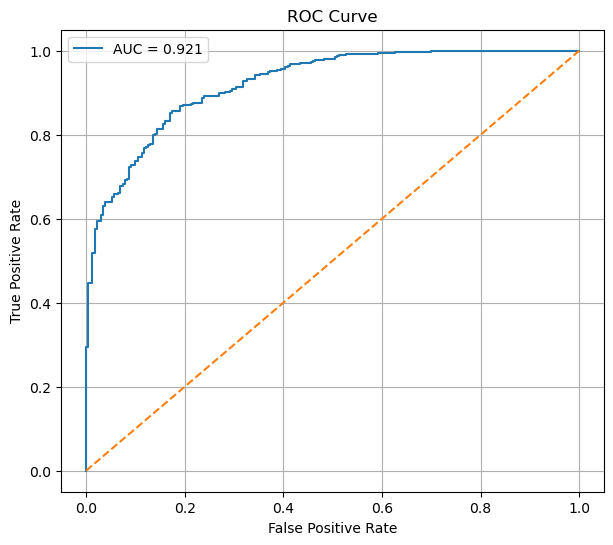

Accuracy : 0.782
Precision: 0.7311
Recall   : 0.7388
F1 Score : 0.7347
ROC AUC  : 0.8287

Confusion Matrix:
[[160  90]
 [104 536]]

Classification Report:
              precision    recall  f1-score   support

   no_nodule       0.61      0.64      0.62       250
      nodule       0.86      0.84      0.85       640

    accuracy                           0.78       890
   macro avg       0.73      0.74      0.73       890
weighted avg       0.79      0.78      0.78       890



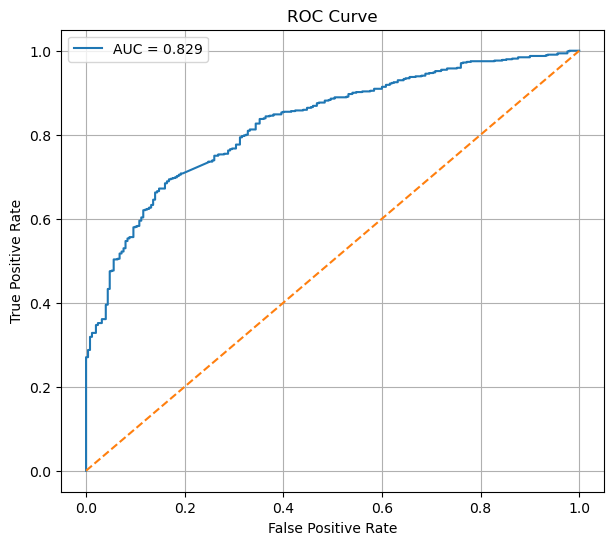

In [58]:
weights=best["weights"]
ensemble_model = WeightedSoftVotingEnsemble(
    models=[resnet50, densenet121],
    weights=weights
).to(device)
val_res = evaluate_ensemble(
    ensemble_model,
    val_loader,
    device,
    class_names
)
test_res = evaluate_ensemble(
    ensemble_model,
    test_loader,
    device,
    class_names
)

## Logistic Regression

In [ ]:
def collect_model_probs(models, loader):
    X_meta = []
    y_meta = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            batch_probs = []
            for model in models:
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                batch_probs.append(probs.cpu().numpy())

            batch_features = np.concatenate(batch_probs, axis=1)
            X_meta.append(batch_features)
            y_meta.append(labels.numpy())

    return np.vstack(X_meta), np.concatenate(y_meta)

In [ ]:
models = [resnet50, densenet121, resnet101]

for model in models:
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

In [ ]:
X_val, y_val = collect_model_probs(models, val_loader)
X_test, y_test = collect_model_probs(models, test_loader)

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_val, y_val)

In [ ]:
test_preds = meta_model.predict(X_test)
test_probs = meta_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds, average="macro", zero_division=0))
print("Recall   :", recall_score(y_test, test_preds, average="macro", zero_division=0))
print("F1 Score :", f1_score(y_test, test_preds, average="macro", zero_division=0))
print("AUC:", roc_auc_score(y_test, test_probs))
print(confusion_matrix(y_test, test_preds))